In [48]:
import pandas as pd
import numpy as np
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_validate
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neural_network import MLPClassifier
import emoji
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

# Load the dataset
df = pd.read_csv('mail_data.csv', encoding='latin-1')

df.columns = ['Category', 'Message']

print("\nRaw Data Sample:")
print(df.iloc[[122]])
print(df.iloc[[191]])
print("\nCategory distribution:")
print(df['Category'].value_counts())

def preprocess_text(text):
    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # 2. Remove most emoticons
    text = re.sub(r'[8:=;][-o*]?[\)\(DOPpS\/\\\]]', '', text)
    # 3. Remove Numbers
    text = re.sub(r'\d+', '', text)
    # 4. Convert to lowercase
    text = text.lower()
    # 5. Replace special characters with whitespace
    text = text.translate(str.maketrans(string.punctuation, ' ' * len(string.punctuation)))
    # 6. Remove extra whitespaces
    text = re.sub(r'\s+', ' ', text).strip()
    # 7. Tokenization
    tokens = word_tokenize(text)
    # 8. Remove Stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]
    # 9. Lemmatization
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]
    # Join tokens back into a string
    text = ' '.join(tokens)
    return text
    
df['Message'] = df['Message'].apply(preprocess_text)

# Map categories to numbers
df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

X = df['Message']
y = df['Category']

print("\nProcessed Data Sample:")
print(X.iloc[[122]])
print(X.iloc[[191]])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# stratify=y ensures equal proportion of 'ham' and 'spam'.
# This means that even unbalanced training sets can be used.

# Vectorize the text data
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


Raw Data Sample:
    Category                                                Message
122      ham  here is my new address -apples&pairs&all that malarky
    Category  \
191     spam   

                                                                      Message  
191  Are you unique enough? Find out from 30th August. www.areyouunique.co.uk  

Category distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64

Processed Data Sample:
122    new address apple pair malarky
Name: Message, dtype: object
191    unique enough find th august
Name: Message, dtype: object



--- Naive Bayes Classifier ---

Cross-Validation Results (Mean across all folds):
Accuracy: 0.9637 (+/- 0.0053)
Precision: 0.9977 (+/- 0.0045)
Recall: 0.7307 (+/- 0.0391)
F1-Score: 0.8430 (+/- 0.0263)


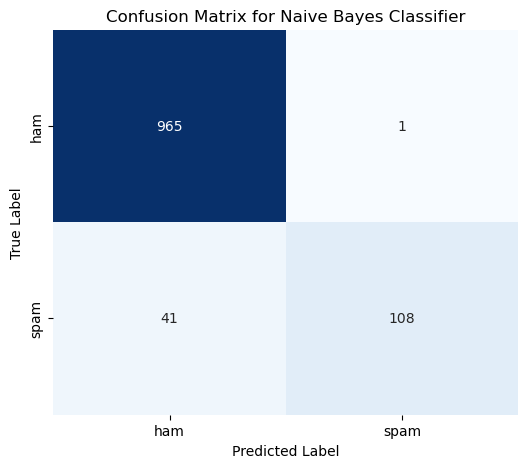


Naive Bayes Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       0.99      0.72      0.84       149

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [38]:
print("\n--- Naive Bayes Classifier ---")
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

# Cross validate predictions

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ['accuracy', 'precision', 'recall', 'f1']
cv_results_nb = cross_validate(nb_model, X_train_tfidf, y_train, cv=cv, scoring=scoring, n_jobs=-1)

# Print the cross-validation results
print("\nCross-Validation Results (Mean across all folds):")
print(f"Accuracy: {np.mean(cv_results_nb['test_accuracy']):.4f} (+/- {np.std(cv_results_nb['test_accuracy']):.4f})")
print(f"Precision: {np.mean(cv_results_nb['test_precision']):.4f} (+/- {np.std(cv_results_nb['test_precision']):.4f})")
print(f"Recall: {np.mean(cv_results_nb['test_recall']):.4f} (+/- {np.std(cv_results_nb['test_recall']):.4f})")
print(f"F1-Score: {np.mean(cv_results_nb['test_f1']):.4f} (+/- {np.std(cv_results_nb['test_f1']):.4f})")

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Naive Bayes Classifier')
plt.show()

print("\nNaive Bayes Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=['ham', 'spam']))


--- Word2Vec with Logistic Regression ---

Shape of Word2Vec vectorized training data: (4457, 100)
Shape of Word2Vec vectorized test data: (1115, 100)

Cross-Validation Results (Mean across all folds):
Accuracy: 0.9527 (+/- 0.0044)
Precision: 0.9803 (+/- 0.0054)
Recall: 0.6606 (+/- 0.0352)
F1-Score: 0.7887 (+/- 0.0237)


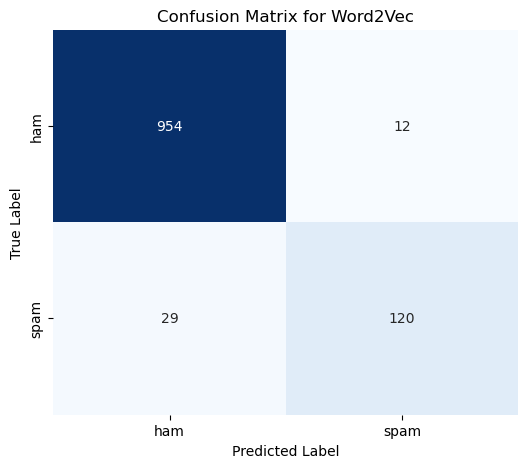


Word2Vec + Logistic Regression Classification Report:
              precision    recall  f1-score   support

         ham       0.97      0.99      0.98       966
        spam       0.91      0.81      0.85       149

    accuracy                           0.96      1115
   macro avg       0.94      0.90      0.92      1115
weighted avg       0.96      0.96      0.96      1115



In [39]:
print("\n--- Word2Vec with Logistic Regression ---")

# Tokenize X_train for Word2Vec training
X_train_tokens = [word_tokenize(message) for message in X_train]
X_test_tokens = [word_tokenize(message) for message in X_test]


# Train Word2Vec model
# vector_size: Dimensionality of the word vectors. Common values are 100, 200, 300.
# window: Maximum distance between the current and predicted word within a sentence.
# min_count: Ignores all words with total frequency lower than this.
# workers: Number of CPU cores to use for training.
# sg: Training algorithm: 0 for CBOW, 1 for skip-gram. Skip-gram is often better for rare words.
word2vec_model = Word2Vec(sentences=X_train_tokens, vector_size=100, window=5, min_count=1, workers=4, sg=0)
word2vec_model.train(X_train_tokens, total_examples=word2vec_model.corpus_count, epochs=10)


# Function to create document vectors by averaging word vectors
def get_document_vector(tokens, model):
    vectors = []
    for word in tokens:
        if word in model.wv:  # Check if the word is in the model's vocabulary
            vectors.append(model.wv[word])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        # Return a zero vector if no words are found in the vocabulary
        return np.zeros(model.vector_size)

# Create document vectors for training and test sets
X_train_w2v = np.array([get_document_vector(tokens, word2vec_model) for tokens in X_train_tokens])
X_test_w2v = np.array([get_document_vector(tokens, word2vec_model) for tokens in X_test_tokens])

print(f"\nShape of Word2Vec vectorized training data: {X_train_w2v.shape}")
print(f"Shape of Word2Vec vectorized test data: {X_test_w2v.shape}")

# Train a Logistic Regression model
lr_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
lr_model.fit(X_train_w2v, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_w2v)

cv_results_lr = cross_validate(lr_model, X_train_tfidf, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("\nCross-Validation Results (Mean across all folds):")
print(f"Accuracy: {np.mean(cv_results_lr['test_accuracy']):.4f} (+/- {np.std(cv_results_lr['test_accuracy']):.4f})")
print(f"Precision: {np.mean(cv_results_lr['test_precision']):.4f} (+/- {np.std(cv_results_lr['test_precision']):.4f})")
print(f"Recall: {np.mean(cv_results_lr['test_recall']):.4f} (+/- {np.std(cv_results_lr['test_recall']):.4f})")
print(f"F1-Score: {np.mean(cv_results_lr['test_f1']):.4f} (+/- {np.std(cv_results_lr['test_f1']):.4f})")

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Word2Vec')
plt.show()

print("\nWord2Vec + Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['ham', 'spam']))


--- Multi-Layer Perceptron (MLP) Classifier ---

Training MLP Classifier...
Iteration 1, loss = 0.66887515
Validation score: 0.921525
Iteration 2, loss = 0.50464791
Validation score: 0.917040
Iteration 3, loss = 0.34315213
Validation score: 0.937220
Iteration 4, loss = 0.22795401
Validation score: 0.959641
Iteration 5, loss = 0.15496020
Validation score: 0.973094
Iteration 6, loss = 0.10989339
Validation score: 0.977578
Iteration 7, loss = 0.08172024
Validation score: 0.979821
Iteration 8, loss = 0.06339134
Validation score: 0.984305
Iteration 9, loss = 0.05060265
Validation score: 0.984305
Iteration 10, loss = 0.04149466
Validation score: 0.984305
Iteration 11, loss = 0.03465516
Validation score: 0.984305
Iteration 12, loss = 0.02940474
Validation score: 0.984305
Iteration 13, loss = 0.02527406
Validation score: 0.984305
Iteration 14, loss = 0.02200450
Validation score: 0.982063
Iteration 15, loss = 0.01925543
Validation score: 0.982063
Iteration 16, loss = 0.01707498
Validation scor

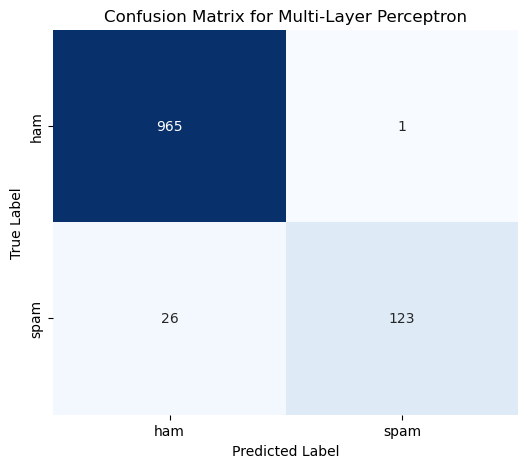


MLP Classifier Classification Report:
              precision    recall  f1-score   support

         ham       0.97      1.00      0.99       966
        spam       0.99      0.83      0.90       149

    accuracy                           0.98      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.98      0.97      1115



In [40]:
print("\n--- Multi-Layer Perceptron (MLP) Classifier ---")

# Initialize the MLP Classifier
# hidden_layer_sizes: A tuple, where the i-th element represents the number of neurons in the i-th hidden layer.
# activation: Activation function for the hidden layer. 'relu' is common.
# solver: The algorithm for weight optimization. 'adam' is a good default.
# alpha: L2 penalty (regularization term) parameter.
# max_iter: Maximum number of iterations (epochs) to run.
# random_state: For reproducibility.
mlp_model = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', alpha=0.0001,
                          max_iter=300, random_state=42, verbose=True, early_stopping=True, n_iter_no_change=10)

# Train the MLP model
print("\nTraining MLP Classifier...")
mlp_model.fit(X_train_tfidf, y_train)

# Make predictions
y_pred_mlp = mlp_model.predict(X_test_tfidf)

cv_results_mlp = cross_validate(mlp_model, X_train_tfidf, y_train, cv=cv, scoring=scoring, n_jobs=-1)

print("\nCross-Validation Results (Mean across all folds):")
print(f"Accuracy: {np.mean(cv_results_mlp['test_accuracy']):.4f} (+/- {np.std(cv_results_mlp['test_accuracy']):.4f})")
print(f"Precision: {np.mean(cv_results_mlp['test_precision']):.4f} (+/- {np.std(cv_results_mlp['test_precision']):.4f})")
print(f"Recall: {np.mean(cv_results_mlp['test_recall']):.4f} (+/- {np.std(cv_results_mlp['test_recall']):.4f})")
print(f"F1-Score: {np.mean(cv_results_mlp['test_f1']):.4f} (+/- {np.std(cv_results_mlp['test_f1']):.4f})")

cm = confusion_matrix(y_test, y_pred_mlp)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Multi-Layer Perceptron')
plt.show()

print("\nMLP Classifier Classification Report:")
print(classification_report(y_test, y_pred_mlp, target_names=['ham', 'spam']))


Comparison of metrics:


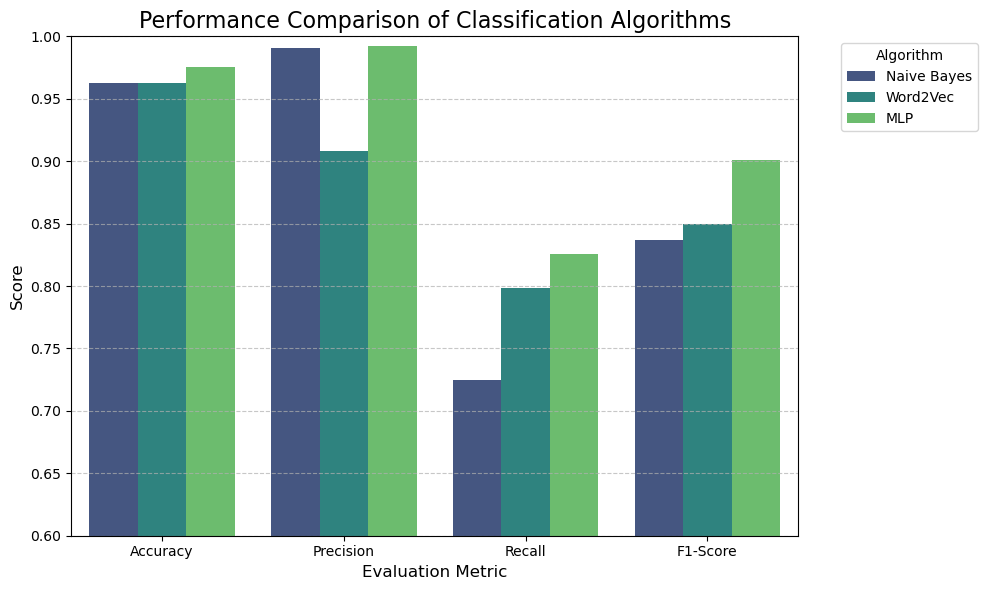

In [44]:
# Comparison of metrics
data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Naive Bayes': [accuracy_nb, precision_nb, recall_nb, f1_nb],
    'Word2Vec': [accuracy_lr, precision_lr, recall_lr, f1_lr],
    'MLP': [accuracy_mlp, precision_mlp, recall_mlp, f1_mlp]
}
df = pd.DataFrame(data)

df_melted = df.melt(id_vars='Metric', var_name='Algorithm', value_name='Score')

# --- Create the Grouped Bar Chart ---
plt.figure(figsize=(10, 6)) # Adjust figure size as needed
sns.barplot(x='Metric', y='Score', hue='Algorithm', data=df_melted, palette='viridis')

plt.title('Performance Comparison of Classification Algorithms', fontsize=16)
plt.xlabel('Evaluation Metric', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.6, 1.0) # This will zoom in on the range from 0.6 to 1.0
plt.legend(title='Algorithm', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()